In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import astropy.units as units
import astropy.constants as const
from scipy.special import wofz
from tqdm import tqdm
from rtfunctions import one_full_fs, sc_2nd_order, calc_lambda_full, calc_lambda_monoc
import time
import illuminated_finite_slab as ill
import SLab_linev2 as v2 # Latest version

<h1>Can Mihalas plots be reproduced?</h1>
<p>In Mihalas' book, there are plots of the source function and the mean intensity for a two-level atom with a given line profile. The question is whether these plots can be reproduced using the code in SLab_linev2.py.</p>
<p>To reproduce Mihalas' plots, we need to ensure that we are using the same parameters and assumptions as Mihalas did in his calculations. This includes the line profile, the optical depth, and the source function. We also need to make sure that we are correctly computing the mean intensity and the source function for the two-level atom.</p>


<h2>SLab_linev2 - one line a = 0.0, Figure 11.3</h2>

In [2]:
# Create a slab
# Define the input parameters
ND = 91
tau_max = 1e4
epsilon_m2 = np.ones(ND) * 1e-2
B = np.ones(ND) * 1.0
H = 80000.0 # Height of the slab above the solar surface in kilometers
slab_one_line = v2.Slab(ND, tau_max, epsilon_m2, B, H)

line_one_1 = v2.Slab.Line(ND, line_center=0.0, a=0.0, k=1.0, slab_in=slab_one_line)
lines_one = [line_one_1]
slab_one_line.global_x_grid(lines_one)
line_one_1.compute_S_line(max_iter = 1000, tol = 1e-6, global_x_grid = slab_one_line.x_values, type = "gaussian")
result_one = slab_one_line.iterate_coupled_lines(lines_one, max_iter=2000, tol=1e-6, verbose=False)

Computed line profile for global x-grid with type: gaussian


  6%|▌         | 59/1000 [00:02<00:33, 27.96it/s]


Convergence achieved after 59 iterations with max dS = 8.20e-07


  0%|          | 3/2000 [00:00<07:53,  4.21it/s]

Final emergent intensity: [1.28834941e-12 6.26879465e-12 2.94369522e-11 1.33401299e-10
 5.83425887e-10 2.46246320e-09 1.00302607e-08 3.94287586e-08
 1.49579607e-07 5.47633527e-07 1.93493272e-06 6.59780392e-06
 2.17114613e-05 6.89493278e-05 2.11304359e-04 6.24863925e-04
 1.78261070e-03 4.90288214e-03 1.29807484e-02 3.29614970e-02
 7.96083588e-02 1.79651346e-01 3.65821285e-01 6.33920700e-01
 8.74378185e-01 9.61825196e-01 9.51757585e-01 9.20223731e-01
 8.74723460e-01 8.14611547e-01 7.41931628e-01 6.61525709e-01
 5.79722812e-01 5.02438747e-01 4.33774973e-01 3.75640876e-01
 3.28169026e-01 2.90412657e-01 2.60960734e-01 2.38343011e-01
 2.21242258e-01 2.08576826e-01 1.99512042e-01 1.93440356e-01
 1.89953201e-01 1.88816237e-01 1.89953201e-01 1.93440356e-01
 1.99512042e-01 2.08576826e-01 2.21242258e-01 2.38343011e-01
 2.60960734e-01 2.90412657e-01 3.28169026e-01 3.75640876e-01
 4.33774973e-01 5.02438747e-01 5.79722812e-01 6.61525709e-01
 7.41931628e-01 8.14611547e-01 8.74723460e-01 9.20223731e-0

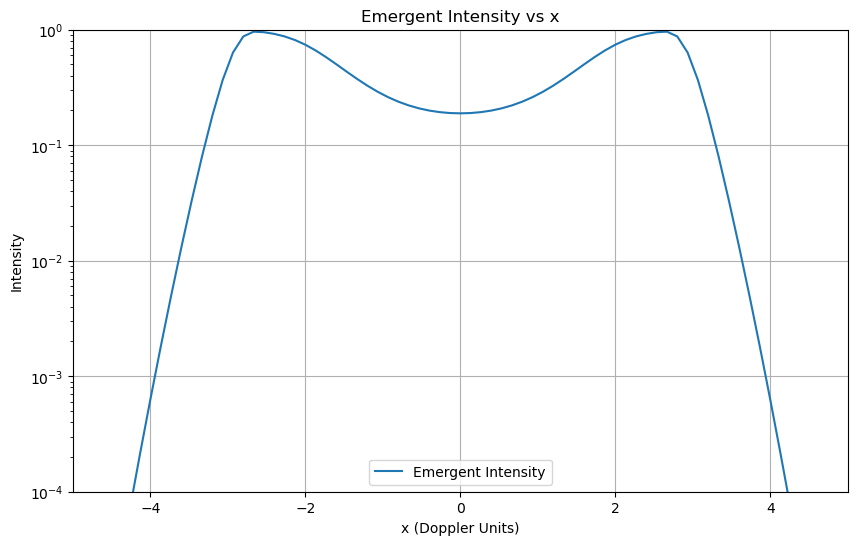

In [3]:
plt.figure(figsize=(10, 6))
plt.semilogy(slab_one_line.x_values, result_one['I_emergent'], label='Emergent Intensity')
plt.xlabel('x (Doppler Units)')
plt.ylabel('Intensity')
plt.xlim(-5, 5)
plt.ylim(1e-4, 1e0)
plt.title('Emergent Intensity vs x')
plt.legend()
plt.grid()
plt.show()

In [4]:
epsilon_m4 = np.ones(ND) * 1e-4
epsilon_m6 = np.ones(ND) * 1e-6
epsilon_m8 = np.ones(ND) * 1e-8
epsilon_m10 = np.ones(ND) * 1e-10

In [5]:
slab_one_line_m4 = v2.Slab(ND, tau_max, epsilon_m4, B, H)
line_one_1_m4 = v2.Slab.Line(ND, line_center=0.0, a=0.0, k=1.0, slab_in=slab_one_line_m4)
lines_one_m4 = [line_one_1_m4]
slab_one_line_m4.global_x_grid(lines_one_m4)
line_one_1_m4.compute_S_line(max_iter = 1000, tol = 1e-6, global_x_grid = slab_one_line_m4.x_values, type = "gaussian")
result_one_m4 = slab_one_line_m4.iterate_coupled_lines(lines_one_m4, max_iter=2000, tol=1e-6, verbose=False)    

Computed line profile for global x-grid with type: gaussian


 11%|█▏        | 114/1000 [00:02<00:20, 42.76it/s]


Convergence achieved after 114 iterations with max dS = 9.82e-07


  2%|▏         | 38/2000 [00:01<01:03, 30.76it/s]

Final emergent intensity: [7.24217426e-13 3.52386572e-12 1.65473384e-11 7.49886209e-11
 3.27960094e-10 1.38421980e-09 5.63829152e-09 2.21640137e-08
 8.40829026e-08 3.07840202e-07 1.08768008e-06 3.70881108e-06
 1.22046228e-05 3.87583561e-05 1.18780125e-04 3.51253613e-04
 1.00205584e-03 2.75604942e-03 7.29684800e-03 1.85285080e-02
 4.47481282e-02 1.00957459e-01 2.05300208e-01 3.53427806e-01
 4.74180974e-01 4.77633868e-01 3.97739797e-01 3.09550035e-01
 2.35105557e-01 1.77056673e-01 1.33560383e-01 1.01628601e-01
 7.84018881e-02 6.15532759e-02 4.93206132e-02 4.04147523e-02
 3.39077892e-02 2.91366062e-02 2.56287878e-02 2.30484672e-02
 2.11575663e-02 1.97883062e-02 1.88238520e-02 1.81848562e-02
 1.78203447e-02 1.77018848e-02 1.78203447e-02 1.81848562e-02
 1.88238520e-02 1.97883062e-02 2.11575663e-02 2.30484672e-02
 2.56287878e-02 2.91366062e-02 3.39077892e-02 4.04147523e-02
 4.93206132e-02 6.15532759e-02 7.84018881e-02 1.01628601e-01
 1.33560383e-01 1.77056673e-01 2.35105557e-01 3.09550035e-0

In [6]:
slab_one_line_m6 = v2.Slab(ND, tau_max, epsilon_m6, B, H)
line_one_1_m6 = v2.Slab.Line(ND, line_center=0.0, a=0.0, k=1.0, slab_in=slab_one_line_m6)
lines_one_m6 = [line_one_1_m6]     
slab_one_line_m6.global_x_grid(lines_one_m6)
line_one_1_m6.compute_S_line(max_iter = 1000, tol = 1e-6, global_x_grid = slab_one_line_m6.x_values, type = "gaussian")
result_one_m6 = slab_one_line_m6.iterate_coupled_lines(lines_one_m6, max_iter=2000, tol=1e-6, verbose=False)

Computed line profile for global x-grid with type: gaussian


 13%|█▎        | 133/1000 [00:03<00:19, 43.97it/s]


Convergence achieved after 133 iterations with max dS = 9.86e-07


 38%|███▊      | 765/2000 [00:19<00:31, 39.21it/s]

Final emergent intensity: [1.75845368e-14 8.55620761e-14 4.01781663e-13 1.82077939e-12
 7.96311458e-12 3.36098844e-11 1.36901904e-10 5.38158710e-10
 2.04159531e-09 7.47458867e-09 2.64096800e-08 9.00526867e-08
 2.96337304e-07 9.41081659e-07 2.88406959e-06 8.52869821e-06
 2.43306572e-05 6.69189043e-05 1.77172690e-04 4.49883945e-04
 1.08649579e-03 2.45107658e-03 4.98235973e-03 8.56121104e-03
 1.13968741e-02 1.11936083e-02 8.87345511e-03 6.54415331e-03
 4.76494560e-03 3.48524869e-03 2.57908936e-03 1.93837123e-03
 1.48357240e-03 1.15883964e-03 9.25481848e-04 7.56726949e-04
 6.33976388e-04 5.44239488e-04 4.78398540e-04 4.30034692e-04
 3.94627670e-04 3.69005953e-04 3.50967593e-04 3.39020158e-04
 3.32206152e-04 3.29991925e-04 3.32206152e-04 3.39020158e-04
 3.50967593e-04 3.69005953e-04 3.94627670e-04 4.30034692e-04
 4.78398540e-04 5.44239488e-04 6.33976388e-04 7.56726949e-04
 9.25481848e-04 1.15883964e-03 1.48357240e-03 1.93837123e-03
 2.57908936e-03 3.48524869e-03 4.76494560e-03 6.54415331e-0

In [7]:
slab_one_line_m8 = v2.Slab(ND, tau_max, epsilon_m8, B, H)
line_one_1_m8 = v2.Slab.Line(ND, line_center=0.0, a=0.0, k=1.0, slab_in=slab_one_line_m8)
lines_one_m8 = [line_one_1_m8]
slab_one_line_m8.global_x_grid(lines_one_m8)
line_one_1_m8.compute_S_line(max_iter = 1000, tol = 1e-6, global_x_grid = slab_one_line_m8.x_values, type = "gaussian")
result_one_m8 = slab_one_line_m8.iterate_coupled_lines(lines_one_m8, max_iter=2000, tol=1e-6, verbose=False)

Computed line profile for global x-grid with type: gaussian


 13%|█▎        | 134/1000 [00:02<00:18, 45.93it/s]


Convergence achieved after 134 iterations with max dS = 9.49e-07


100%|██████████| 2000/2000 [00:50<00:00, 39.48it/s]

Final emergent intensity: [1.87553187e-16 9.12588156e-16 4.28532364e-15 1.94200724e-14
 8.49330029e-14 3.58476370e-13 1.46016859e-12 5.73989420e-12
 2.17752511e-11 7.97224823e-11 2.81680415e-10 9.60484120e-10
 3.16067498e-09 1.00373906e-08 3.07609150e-08 9.09654063e-08
 2.59505975e-07 7.13743812e-07 1.88968910e-06 4.79837581e-06
 1.15883782e-05 2.61430167e-05 5.31440490e-05 9.13380530e-05
 1.21704804e-04 1.19895796e-04 9.55961214e-05 7.08947740e-05
 5.17572486e-05 3.78573621e-05 2.79815413e-05 2.10029899e-05
 1.60586472e-05 1.25345670e-05 1.00055250e-05 8.17836899e-06
 6.85019121e-06 5.87966715e-06 5.16780736e-06 4.64502173e-06
 4.26235123e-06 3.98546807e-06 3.79054985e-06 3.66145531e-06
 3.58783086e-06 3.56390678e-06 3.58783086e-06 3.66145531e-06
 3.79054985e-06 3.98546807e-06 4.26235123e-06 4.64502173e-06
 5.16780736e-06 5.87966715e-06 6.85019121e-06 8.17836899e-06
 1.00055250e-05 1.25345670e-05 1.60586472e-05 2.10029899e-05
 2.79815413e-05 3.78573621e-05 5.17572486e-05 7.08947740e-0

In [8]:
slab_one_line_m10 = v2.Slab(ND, tau_max, epsilon_m10, B, H)
line_one_1_m10 = v2.Slab.Line(ND, line_center=0.0, a=0.0, k=1.0, slab_in=slab_one_line_m10)
lines_one_m10 = [line_one_1_m10]
slab_one_line_m10.global_x_grid(lines_one_m10)
line_one_1_m10.compute_S_line(max_iter = 1000, tol = 1e-6, global_x_grid = slab_one_line_m10.x_values, type = "gaussian")
result_one_m10 = slab_one_line_m10.iterate_coupled_lines(lines_one_m10, max_iter=2000, tol=1e-6, verbose=False)

Computed line profile for global x-grid with type: gaussian


 13%|█▎        | 134/1000 [00:02<00:17, 48.69it/s]


Convergence achieved after 134 iterations with max dS = 9.50e-07


100%|██████████| 2000/2000 [00:48<00:00, 40.90it/s]

Final emergent intensity: [1.10205704e-17 5.36234131e-17 2.51804364e-16 1.14111777e-15
 4.99063841e-15 2.10639666e-14 8.57990796e-14 3.37274505e-13
 1.27950739e-12 4.68446974e-12 1.65514588e-11 5.64377660e-11
 1.85720338e-10 5.89794141e-10 1.80750243e-09 5.34510117e-09
 1.52484994e-08 4.19394128e-08 1.11037885e-07 2.81954101e-07
 6.80961038e-07 1.53649724e-06 3.12613518e-06 5.39465679e-06
 7.30961263e-06 7.58769316e-06 6.64092412e-06 5.35178339e-06
 4.06873570e-06 2.99297761e-06 2.18903544e-06 1.62099563e-06
 1.22543253e-06 9.48642312e-07 7.52915645e-07 6.13021726e-07
 5.12098597e-07 4.38740744e-07 3.85132455e-07 3.45864775e-07
 3.17174020e-07 2.96441462e-07 2.81859440e-07 2.72207609e-07
 2.66705095e-07 2.64917387e-07 2.66705095e-07 2.72207609e-07
 2.81859440e-07 2.96441462e-07 3.17174020e-07 3.45864775e-07
 3.85132455e-07 4.38740744e-07 5.12098597e-07 6.13021726e-07
 7.52915645e-07 9.48642312e-07 1.22543253e-06 1.62099563e-06
 2.18903544e-06 2.99297761e-06 4.06873570e-06 5.35178339e-0

In [9]:
S_e2 = result_one['S_lines'][0]
I_e2 = result_one['I_emergent']

S_e4 = result_one_m4['S_lines'][0]
I_e4 = result_one_m4['I_emergent']

S_e6 = result_one_m6['S_lines'][0]
I_e6 = result_one_m6['I_emergent']

S_e8 = result_one_m8['S_lines'][0]
I_e8 = result_one_m8['I_emergent']

S_e10 = result_one_m10['S_lines'][0]
I_e10 = result_one_m10['I_emergent']

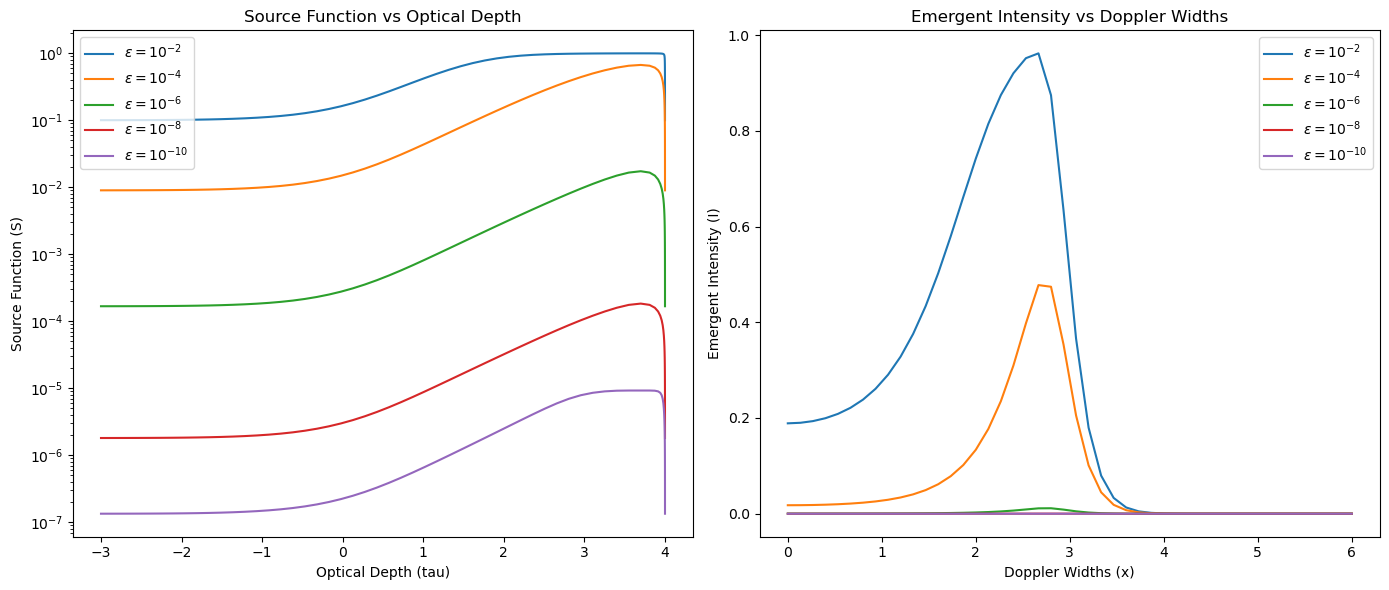

In [10]:
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.semilogy(np.log10(slab_one_line.tau), S_e2, label=r'$\epsilon = 10^{-2}$')
plt.semilogy(np.log10(slab_one_line_m4.tau), S_e4, label=r'$\epsilon = 10^{-4}$')
plt.semilogy(np.log10(slab_one_line_m6.tau), S_e6, label=r'$\epsilon = 10^{-6}$')
plt.semilogy(np.log10(slab_one_line_m8.tau), S_e8, label=r'$\epsilon = 10^{-8}$')
plt.semilogy(np.log10(slab_one_line_m10.tau), S_e10, label=r'$\epsilon = 10^{-10}$')
plt.xlabel('Optical Depth (tau)')
plt.ylabel('Source Function (S)')
plt.title('Source Function vs Optical Depth')
plt.legend()
plt.subplot(1, 2, 2)
midpoint = len(slab_one_line.x_values) // 2
I_e2_half = I_e2[midpoint:]
I_e4_half = I_e4[midpoint:]
I_e6_half = I_e6[midpoint:]
I_e8_half = I_e8[midpoint:]
I_e10_half = I_e10[midpoint:]
plt.plot(slab_one_line.x_values[midpoint:], I_e2_half, label=r'$\epsilon = 10^{-2}$')
plt.plot(slab_one_line_m4.x_values[midpoint:], I_e4_half, label=r'$\epsilon = 10^{-4}$')
plt.plot(slab_one_line_m6.x_values[midpoint:], I_e6_half, label=r'$\epsilon = 10^{-6}$')
plt.plot(slab_one_line_m8.x_values[midpoint:], I_e8_half, label=r'$\epsilon = 10^{-8}$')
plt.plot(slab_one_line_m10.x_values[midpoint:], I_e10_half, label=r'$\epsilon = 10^{-10}$')
plt.xlabel('Doppler Widths (x)')
plt.ylabel('Emergent Intensity (I)')
plt.title('Emergent Intensity vs Doppler Widths')
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
print(I_e10)

[1.10205704e-17 5.36234131e-17 2.51804364e-16 1.14111777e-15
 4.99063841e-15 2.10639666e-14 8.57990796e-14 3.37274505e-13
 1.27950739e-12 4.68446974e-12 1.65514588e-11 5.64377660e-11
 1.85720338e-10 5.89794141e-10 1.80750243e-09 5.34510117e-09
 1.52484994e-08 4.19394128e-08 1.11037885e-07 2.81954101e-07
 6.80961038e-07 1.53649724e-06 3.12613518e-06 5.39465679e-06
 7.30961263e-06 7.58769316e-06 6.64092412e-06 5.35178339e-06
 4.06873570e-06 2.99297761e-06 2.18903544e-06 1.62099563e-06
 1.22543253e-06 9.48642312e-07 7.52915645e-07 6.13021726e-07
 5.12098597e-07 4.38740744e-07 3.85132455e-07 3.45864775e-07
 3.17174020e-07 2.96441462e-07 2.81859440e-07 2.72207609e-07
 2.66705095e-07 2.64917387e-07 2.66705095e-07 2.72207609e-07
 2.81859440e-07 2.96441462e-07 3.17174020e-07 3.45864775e-07
 3.85132455e-07 4.38740744e-07 5.12098597e-07 6.13021726e-07
 7.52915645e-07 9.48642312e-07 1.22543253e-06 1.62099563e-06
 2.18903544e-06 2.99297761e-06 4.06873570e-06 5.35178339e-06
 6.64092412e-06 7.587693

<h2>SLab_linev2 - one line a = {0.0; 0.01, 0.001}, Figure 11.4</h2>

In [12]:
ND = 91
tau_max_dep2 = 1e2
B = np.ones(ND) * 1.0
H = 80000.0 # Height of the slab above the solar surface in kilometers
slab_one_line_dep2 = v2.Slab(ND, tau_max_dep2, epsilon_m4, B, H)

line_one_0_dep2 = v2.Slab.Line(ND, line_center=0.0, a=0.0, k=1.0, slab_in=slab_one_line_dep2)
lines_one_0_dep2 = [line_one_0_dep2]

line_one_02_dep2 = v2.Slab.Line(ND, line_center=0.0, a=0.01, k=1.0, slab_in=slab_one_line_dep2)
lines_one_02_dep2 = [line_one_02_dep2]

line_one_03_dep2 = v2.Slab.Line(ND, line_center=0.0, a=0.001, k=1.0, slab_in=slab_one_line_dep2)
lines_one_03_dep2 = [line_one_03_dep2]

slab_one_line_dep2.global_x_grid(lines_one_0_dep2)
line_one_0_dep2.compute_S_line(max_iter = 1000, tol = 1e-6, global_x_grid = slab_one_line_dep2.x_values, type = "gaussian")
result_one_0_dep2 = slab_one_line_dep2.iterate_coupled_lines(lines_one_0_dep2, max_iter=2000, tol=1e-6, verbose=False)

slab_one_line_dep2.global_x_grid(lines_one_02_dep2)
line_one_02_dep2.compute_S_line(max_iter = 1000, tol = 1e-6, global_x_grid = slab_one_line_dep2.x_values)
result_one_02_dep2 = slab_one_line_dep2.iterate_coupled_lines(lines_one_02_dep2, max_iter=2000, tol=1e-6, verbose=False)

slab_one_line_dep2.global_x_grid(lines_one_03_dep2)
line_one_03_dep2.compute_S_line(max_iter = 1000, tol = 1e-6, global_x_grid = slab_one_line_dep2.x_values)
result_one_03_dep2 = slab_one_line_dep2.iterate_coupled_lines(lines_one_03_dep2, max_iter=2000, tol=1e-6, verbose=False)

S_0_dep2 = result_one_0_dep2['S_lines'][0]
I_0_dep2 = result_one_0_dep2['I_emergent']

S_02_dep2 = result_one_02_dep2['S_lines'][0]
I_02_dep2 = result_one_02_dep2['I_emergent']

S_03_dep2 = result_one_03_dep2['S_lines'][0]
I_03_dep2 = result_one_03_dep2['I_emergent']

Computed line profile for global x-grid with type: gaussian


 14%|█▍        | 140/1000 [00:03<00:23, 36.32it/s]


Convergence achieved after 140 iterations with max dS = 9.62e-07


 12%|█▏        | 237/2000 [00:06<00:50, 34.95it/s]


Final emergent intensity: [1.07649170e-16 5.23794660e-16 2.45963047e-15 1.11464631e-14
 4.87486639e-14 2.05753282e-13 8.38087269e-13 3.29450472e-12
 1.24982568e-11 4.57580143e-11 1.61675165e-10 5.51287147e-10
 1.81414007e-09 5.76132154e-09 1.76575978e-08 5.22274648e-08
 1.49081257e-07 4.10677789e-07 1.09175887e-06 2.80080918e-06
 6.93321580e-06 1.65576656e-05 3.81333629e-05 8.46263079e-05
 1.80687185e-04 3.70107534e-04 7.23641774e-04 1.33935068e-03
 2.31656090e-03 3.67696271e-03 5.23821359e-03 6.55902926e-03
 7.15812370e-03 6.92606903e-03 6.20070860e-03 5.38032554e-03
 4.65974004e-03 4.08141689e-03 3.63397075e-03 3.29434402e-03
 3.04036757e-03 2.85396744e-03 2.72149042e-03 2.63320125e-03
 2.58265773e-03 2.56620434e-03 2.58265773e-03 2.63320125e-03
 2.72149042e-03 2.85396744e-03 3.04036757e-03 3.29434402e-03
 3.63397075e-03 4.08141689e-03 4.65974004e-03 5.38032554e-03
 6.20070860e-03 6.92606903e-03 7.15812370e-03 6.55902926e-03
 5.23821359e-03 3.67696271e-03 2.31656090e-03 1.33935068e-0

...

Final emergent intensity: [6.46322423e-05 6.77330888e-05 7.10665601e-05 7.46569985e-05
 7.85320924e-05 8.27234590e-05 8.72673549e-05 9.22055458e-05
 9.75863840e-05 1.03466156e-04 1.09910794e-04 1.16998111e-04
 1.24820814e-04 1.33490841e-04 1.43146131e-04 1.53962306e-04
 1.66174737e-04 1.80122943e-04 1.96342586e-04 2.15756103e-04
 2.40059975e-04 2.72484478e-04 3.19214764e-04 3.91883605e-04
 5.11553038e-04 7.14118946e-04 1.05520878e-03 1.60792744e-03
 2.43890627e-03 3.54501078e-03 4.76208473e-03 5.74205309e-03
 6.13691962e-03 5.89666652e-03 5.29300324e-03 4.62442850e-03
 4.03492935e-03 3.55721282e-03 3.18394053e-03 2.89818516e-03
 2.68300602e-03 2.52421967e-03 2.41090450e-03 2.33516431e-03
 2.29172312e-03 2.27756872e-03 2.29172312e-03 2.33516431e-03
 2.41090450e-03 2.52421967e-03 2.68300602e-03 2.89818516e-03
 3.18394053e-03 3.55721282e-03 4.03492935e-03 4.62442850e-03
 5.29300324e-03 5.89666652e-03 6.13691962e-03 5.74205309e-03
 4.76208473e-03 3.54501078e-03 2.43890627e-03 1.60792744e-0

 14%|█▍        | 138/1000 [00:02<00:15, 56.16it/s]


Convergence achieved after 138 iterations with max dS = 9.71e-07


 12%|█▏        | 236/2000 [00:06<00:47, 37.15it/s]

Final emergent intensity: [7.46063455e-06 7.82013989e-06 8.20677648e-06 8.62340476e-06
 9.07328188e-06 9.56013158e-06 1.00882295e-05 1.06625085e-05
 1.12886905e-05 1.19734573e-05 1.27246826e-05 1.35517836e-05
 1.44663296e-05 1.54832765e-05 1.66237625e-05 1.79218121e-05
 1.94405840e-05 2.13111470e-05 2.38222833e-05 2.76207496e-05
 3.41390867e-05 4.64670697e-05 7.10337632e-05 1.20649477e-04
 2.19540554e-04 4.10558972e-04 7.62650025e-04 1.37087291e-03
 2.33058746e-03 3.66040021e-03 5.18001641e-03 6.45933481e-03
 7.03335882e-03 6.80016286e-03 6.08965749e-03 5.28786369e-03
 4.58331230e-03 4.01726950e-03 3.57886143e-03 3.24579168e-03
 2.99653491e-03 2.81349346e-03 2.68334723e-03 2.59658470e-03
 2.54690533e-03 2.53073168e-03 2.54690533e-03 2.59658470e-03
 2.68334723e-03 2.81349346e-03 2.99653491e-03 3.24579168e-03
 3.57886143e-03 4.01726950e-03 4.58331230e-03 5.28786369e-03
 6.08965749e-03 6.80016286e-03 7.03335882e-03 6.45933481e-03
 5.18001641e-03 3.66040021e-03 2.33058746e-03 1.37087291e-0

In [13]:
tau_max_dep4 = 1e4
slab_one_line_dep4 = v2.Slab(ND, tau_max_dep4, epsilon_m4, B, H)

line_one_0_dep4 = v2.Slab.Line(ND, line_center=0.0, a=0.0, k=1.0, slab_in=slab_one_line_dep4)
lines_one_0_dep4 = [line_one_0_dep4]
line_one_02_dep4 = v2.Slab.Line(ND, line_center=0.0, a=0.01, k=1.0, slab_in=slab_one_line_dep4)
lines_one_02_dep4 = [line_one_02_dep4]
line_one_03_dep4 = v2.Slab.Line(ND, line_center=0.0, a=0.001, k=1.0, slab_in=slab_one_line_dep4)
lines_one_03_dep4 = [line_one_03_dep4]

slab_one_line_dep4.global_x_grid(lines_one_0_dep4)
line_one_0_dep4.compute_S_line(max_iter = 1000, tol = 1e-6, global_x_grid = slab_one_line_dep4.x_values, type = "gaussian")
result_one_0_dep4 = slab_one_line_dep4.iterate_coupled_lines(lines_one_0_dep4, max_iter=2000, tol=1e-6, verbose=False)

slab_one_line_dep4.global_x_grid(lines_one_02_dep4)
line_one_02_dep4.compute_S_line(max_iter = 1000, tol = 1e-6, global_x_grid = slab_one_line_dep4.x_values)
result_one_02_dep4 = slab_one_line_dep4.iterate_coupled_lines(lines_one_02_dep4, max_iter=2000, tol=1e-6, verbose=False)

slab_one_line_dep4.global_x_grid(lines_one_03_dep4)
line_one_03_dep4.compute_S_line(max_iter = 1000, tol = 1e-6, global_x_grid = slab_one_line_dep4.x_values)
result_one_03_dep4 = slab_one_line_dep4.iterate_coupled_lines(lines_one_03_dep4, max_iter=2000, tol=1e-6, verbose=False)

S_0_dep4 = result_one_0_dep4['S_lines'][0]
I_0_dep4 = result_one_0_dep4['I_emergent']

S_02_dep4 = result_one_02_dep4['S_lines'][0]
I_02_dep4 = result_one_02_dep4['I_emergent']

S_03_dep4 = result_one_03_dep4['S_lines'][0]
I_03_dep4 = result_one_03_dep4['I_emergent']

Computed line profile for global x-grid with type: gaussian


 11%|█▏        | 114/1000 [00:02<00:17, 50.74it/s]


Convergence achieved after 114 iterations with max dS = 9.82e-07


  2%|▏         | 38/2000 [00:01<00:52, 37.40it/s]


Final emergent intensity: [7.24217426e-13 3.52386572e-12 1.65473384e-11 7.49886209e-11
 3.27960094e-10 1.38421980e-09 5.63829152e-09 2.21640137e-08
 8.40829026e-08 3.07840202e-07 1.08768008e-06 3.70881108e-06
 1.22046228e-05 3.87583561e-05 1.18780125e-04 3.51253613e-04
 1.00205584e-03 2.75604942e-03 7.29684800e-03 1.85285080e-02
 4.47481282e-02 1.00957459e-01 2.05300208e-01 3.53427806e-01
 4.74180974e-01 4.77633868e-01 3.97739797e-01 3.09550035e-01
 2.35105557e-01 1.77056673e-01 1.33560383e-01 1.01628601e-01
 7.84018881e-02 6.15532759e-02 4.93206132e-02 4.04147523e-02
 3.39077892e-02 2.91366062e-02 2.56287878e-02 2.30484672e-02
 2.11575663e-02 1.97883062e-02 1.88238520e-02 1.81848562e-02
 1.78203447e-02 1.77018848e-02 1.78203447e-02 1.81848562e-02
 1.88238520e-02 1.97883062e-02 2.11575663e-02 2.30484672e-02
 2.56287878e-02 2.91366062e-02 3.39077892e-02 4.04147523e-02
 4.93206132e-02 6.15532759e-02 7.84018881e-02 1.01628601e-01
 1.33560383e-01 1.77056673e-01 2.35105557e-01 3.09550035e-0

...

Final emergent intensity: [0.1439251  0.14795808 0.152085   0.15629892 0.16059072 0.1649487
 0.16935812 0.17380071 0.17825409 0.18269109 0.18707914 0.19137948
 0.19554646 0.19952697 0.20325992 0.20667601 0.20969742 0.21223607
 0.21418643 0.21540301 0.21564225 0.21443964 0.21092085 0.20372042
 0.19151448 0.17427854 0.15368141 0.13193658 0.11083854 0.0915422
 0.0746911  0.06054404 0.04905624 0.03997211 0.03292912 0.02754326
 0.02346185 0.02038706 0.0180805  0.01635821 0.01508192 0.01415006
 0.01348975 0.01305044 0.01279917 0.01271741 0.01279917 0.01305044
 0.01348975 0.01415006 0.01508192 0.01635821 0.0180805  0.02038706
 0.02346185 0.02754326 0.03292912 0.03997211 0.04905624 0.06054404
 0.0746911  0.0915422  0.11083854 0.13193658 0.15368141 0.17427854
 0.19151448 0.20372042 0.21092085 0.21443964 0.21564225 0.21540301
 0.21418643 0.21223607 0.20969742 0.20667601 0.20325992 0.19952697
 0.19554646 0.19137948 0.18707914 0.18269109 0.17825409 0.17380071
 0.16935812 0.1649487  0.16059072 0.15

 11%|█         | 109/1000 [00:02<00:16, 54.28it/s]


Convergence achieved after 109 iterations with max dS = 9.18e-07


  2%|▏         | 44/2000 [00:01<00:52, 37.09it/s]

Final emergent intensity: [0.03358252 0.03512426 0.03677476 0.0385445  0.0404453  0.04249047
 0.04469507 0.0470762  0.04965337 0.05244893 0.05548872 0.05880303
 0.06242846 0.06641191 0.07081994 0.07576166 0.08144344 0.08829539
 0.0972463  0.11026355 0.13120677 0.16639806 0.22191869 0.29119831
 0.33863    0.32808896 0.2794427  0.22534561 0.17664916 0.13637768
 0.1047746  0.08076961 0.06287975 0.04968014 0.03998285 0.03286447
 0.02763336 0.02378196 0.02094206 0.01884863 0.01731217 0.01619832
 0.01541315 0.01489265 0.01459563 0.01449908 0.01459563 0.01489265
 0.01541315 0.01619832 0.01731217 0.01884863 0.02094206 0.02378196
 0.02763336 0.03286447 0.03998285 0.04968014 0.06287975 0.08076961
 0.1047746  0.13637768 0.17664916 0.22534561 0.2794427  0.32808896
 0.33863    0.29119831 0.22191869 0.16639806 0.13120677 0.11026355
 0.0972463  0.08829539 0.08144344 0.07576166 0.07081994 0.06641191
 0.06242846 0.05880303 0.05548872 0.05244893 0.04965337 0.0470762
 0.04469507 0.04249047 0.0404453  0.0

In [14]:
tau_max_dep6 = 1e6
slab_one_line_dep6 = v2.Slab(ND, tau_max_dep6, epsilon_m4, B, H)

line_one_0_dep6 = v2.Slab.Line(ND, line_center=0.0, a=0.0, k=1.0, slab_in=slab_one_line_dep6)
lines_one_0_dep6 = [line_one_0_dep6]
line_one_02_dep6 = v2.Slab.Line(ND, line_center=0.0, a=0.01, k=1.0, slab_in=slab_one_line_dep6)
lines_one_02_dep6 = [line_one_02_dep6]
line_one_03_dep6 = v2.Slab.Line(ND, line_center=0.0, a=0.001, k=1.0, slab_in=slab_one_line_dep6)
lines_one_03_dep6 = [line_one_03_dep6]

slab_one_line_dep6.global_x_grid(lines_one_0_dep6)
line_one_0_dep6.compute_S_line(max_iter = 1000, tol = 1e-6, global_x_grid = slab_one_line_dep6.x_values, type = "gaussian")
result_one_0_dep6 = slab_one_line_dep6.iterate_coupled_lines(lines_one_0_dep6, max_iter=2000, tol=1e-6, verbose=False)

slab_one_line_dep6.global_x_grid(lines_one_02_dep6)
line_one_02_dep6.compute_S_line(max_iter = 1000, tol = 1e-6, global_x_grid = slab_one_line_dep6.x_values)
result_one_02_dep6 = slab_one_line_dep6.iterate_coupled_lines(lines_one_02_dep6, max_iter=2000, tol=1e-6, verbose=False)

slab_one_line_dep6.global_x_grid(lines_one_03_dep6)
line_one_03_dep6.compute_S_line(max_iter = 1000, tol = 1e-6, global_x_grid = slab_one_line_dep6.x_values)
result_one_03_dep6 = slab_one_line_dep6.iterate_coupled_lines(lines_one_03_dep6, max_iter=2000, tol=1e-6, verbose=False)

S_0_dep6 = result_one_0_dep6['S_lines'][0]
I_0_dep6 = result_one_0_dep6['I_emergent']

S_02_dep6 = result_one_02_dep6['S_lines'][0]
I_02_dep6 = result_one_02_dep6['I_emergent']

S_03_dep6 = result_one_03_dep6['S_lines'][0]
I_03_dep6 = result_one_03_dep6['I_emergent']

Computed line profile for global x-grid with type: gaussian


  9%|▊         | 86/1000 [00:02<00:23, 39.14it/s]


Convergence achieved after 86 iterations with max dS = 9.83e-07


  1%|▏         | 28/2000 [00:00<00:54, 35.90it/s]


Final emergent intensity: [1.29322085e-10 6.29249788e-10 2.95482576e-09 1.33905708e-08
 5.85631888e-08 2.47177383e-07 1.00681815e-06 3.95777660e-06
 1.50144061e-05 5.49689076e-05 1.94206007e-04 6.62055499e-04
 2.17697854e-03 6.89706841e-03 2.09865879e-02 6.07924208e-02
 1.63804548e-01 3.88339676e-01 7.25434780e-01 9.49810047e-01
 9.66259212e-01 9.34449656e-01 8.80355969e-01 7.99392718e-01
 6.93682981e-01 5.74067776e-01 4.55708684e-01 3.50948995e-01
 2.65575470e-01 1.99726823e-01 1.50596560e-01 1.14590551e-01
 8.84154150e-02 6.94287241e-02 5.56407970e-02 4.55995603e-02
 3.82607826e-02 3.28782708e-02 2.89202216e-02 2.60083260e-02
 2.38742612e-02 2.23288409e-02 2.12402753e-02 2.05190389e-02
 2.01076105e-02 1.99739029e-02 2.01076105e-02 2.05190389e-02
 2.12402753e-02 2.23288409e-02 2.38742612e-02 2.60083260e-02
 2.89202216e-02 3.28782708e-02 3.82607826e-02 4.55995603e-02
 5.56407970e-02 6.94287241e-02 8.84154150e-02 1.14590551e-01
 1.50596560e-01 1.99726823e-01 2.65575470e-01 3.50948995e-0

...

Final emergent intensity: [0.64196975 0.63340953 0.62461971 0.61559574 0.60633313 0.59682742
 0.58707418 0.57706893 0.56680717 0.55628422 0.54549508 0.53443423
 0.52309505 0.51146882 0.49954246 0.48729381 0.47468167 0.46162587
 0.44796978 0.43341582 0.41743004 0.39914083 0.37733431 0.35075991
 0.31889915 0.28278093 0.24484143 0.2077125  0.17325303 0.14251289
 0.11602615 0.09394484 0.07607799 0.06197427 0.05104837 0.04269592
 0.03636707 0.03159921 0.02802259 0.02535194 0.02337291 0.02192798
 0.02090413 0.02022296 0.01983336 0.01970659 0.01983336 0.02022296
 0.02090413 0.02192798 0.02337291 0.02535194 0.02802259 0.03159921
 0.03636707 0.04269592 0.05104837 0.06197427 0.07607799 0.09394484
 0.11602615 0.14251289 0.17325303 0.2077125  0.24484143 0.28278093
 0.31889915 0.35075991 0.37733431 0.39914083 0.41743004 0.43341582
 0.44796978 0.46162587 0.47468167 0.48729381 0.49954246 0.51146882
 0.52309505 0.53443423 0.54549508 0.55628422 0.56680717 0.57706893
 0.58707418 0.59682742 0.60633313 0.

  8%|▊         | 82/1000 [00:02<00:24, 37.59it/s]


Convergence achieved after 82 iterations with max dS = 9.95e-07


  1%|▏         | 29/2000 [00:00<01:03, 31.11it/s]

Final emergent intensity: [0.91017785 0.90708979 0.90383327 0.90040173 0.89678711 0.89297977
 0.8889685  0.88474044 0.880281   0.8755737  0.8705998  0.86533755
 0.85976039 0.85383248 0.84749771 0.84065339 0.83308952 0.82435781
 0.81351602 0.79871596 0.77680169 0.74359779 0.6957127  0.63277833
 0.55755164 0.47475671 0.39062995 0.31184233 0.24343778 0.18760518
 0.14403196 0.11101361 0.08642978 0.06829575 0.05497218 0.04518969
 0.03799897 0.03270362 0.02879833 0.02591921 0.02380595 0.02227389
 0.02119388 0.02047793 0.02006937 0.01993658 0.02006937 0.02047793
 0.02119388 0.02227389 0.02380595 0.02591921 0.02879833 0.03270362
 0.03799897 0.04518969 0.05497218 0.06829575 0.08642978 0.11101361
 0.14403196 0.18760518 0.24343778 0.31184233 0.39062995 0.47475671
 0.55755164 0.63277833 0.6957127  0.74359779 0.77680169 0.79871596
 0.81351602 0.82435781 0.83308952 0.84065339 0.84749771 0.85383248
 0.85976039 0.86533755 0.8705998  0.8755737  0.880281   0.88474044
 0.8889685  0.89297977 0.89678711 0.

In [15]:
tau_max_dep8 = 1e8
slab_one_line_dep8 = v2.Slab(ND, tau_max_dep8, epsilon_m4, B, H)

line_one_0_dep8 = v2.Slab.Line(ND, line_center=0.0, a=0.0, k=1.0, slab_in=slab_one_line_dep8)
lines_one_0_dep8 = [line_one_0_dep8]
line_one_02_dep8 = v2.Slab.Line(ND, line_center=0.0, a=0.01, k=1.0, slab_in=slab_one_line_dep8)
lines_one_02_dep8 = [line_one_02_dep8]
line_one_03_dep8 = v2.Slab.Line(ND, line_center=0.0, a=0.001, k=1.0, slab_in=slab_one_line_dep8)
lines_one_03_dep8 = [line_one_03_dep8]

slab_one_line_dep8.global_x_grid(lines_one_0_dep8)
line_one_0_dep8.compute_S_line(max_iter = 1000, tol = 1e-6, global_x_grid = slab_one_line_dep8.x_values, type = "gaussian")
result_one_0_dep8 = slab_one_line_dep8.iterate_coupled_lines(lines_one_0_dep8, max_iter=2000, tol=1e-6, verbose=False)

slab_one_line_dep8.global_x_grid(lines_one_02_dep8)
line_one_02_dep8.compute_S_line(max_iter = 1000, tol = 1e-6, global_x_grid = slab_one_line_dep8.x_values)
result_one_02_dep8 = slab_one_line_dep8.iterate_coupled_lines(lines_one_02_dep8, max_iter=2000, tol=1e-6, verbose=False)

slab_one_line_dep8.global_x_grid(lines_one_03_dep8)
line_one_03_dep8.compute_S_line(max_iter = 1000, tol = 1e-6, global_x_grid = slab_one_line_dep8.x_values)
result_one_03_dep8 = slab_one_line_dep8.iterate_coupled_lines(lines_one_03_dep8, max_iter=2000, tol=1e-6, verbose=False)

S_0_dep8 = result_one_0_dep8['S_lines'][0]
I_0_dep8 = result_one_0_dep8['I_emergent']

S_02_dep8 = result_one_02_dep8['S_lines'][0]
I_02_dep8 = result_one_02_dep8['I_emergent']

S_03_dep8 = result_one_03_dep8['S_lines'][0]
I_03_dep8 = result_one_03_dep8['I_emergent']

Computed line profile for global x-grid with type: gaussian


  7%|▋         | 69/1000 [00:01<00:22, 42.01it/s]


Convergence achieved after 69 iterations with max dS = 8.83e-07


  1%|          | 21/2000 [00:00<00:45, 43.85it/s]


Final emergent intensity: [1.30842505e-08 6.36647764e-08 2.98956476e-07 1.35479927e-06
 5.92515337e-06 2.50080314e-05 1.01860379e-04 4.00351386e-04
 1.51795091e-03 5.54623152e-03 1.94590051e-02 6.48103895e-02
 1.97878941e-01 5.03516099e-01 8.82926121e-01 9.97805738e-01
 9.98855355e-01 9.97164904e-01 9.93293062e-01 9.84924509e-01
 9.68001913e-01 9.36402226e-01 8.82892856e-01 8.02445382e-01
 6.97000633e-01 5.77347787e-01 4.58723988e-01 3.53586696e-01
 2.67811293e-01 2.01586529e-01 1.52127470e-01 1.15845287e-01
 8.94439910e-02 7.02753545e-02 5.63430828e-02 4.61887359e-02
 3.87623450e-02 3.33127015e-02 2.93037231e-02 2.63535594e-02
 2.41910613e-02 2.26248719e-02 2.15215992e-02 2.07905876e-02
 2.03735731e-02 2.02380486e-02 2.03735731e-02 2.07905876e-02
 2.15215992e-02 2.26248719e-02 2.41910613e-02 2.63535594e-02
 2.93037231e-02 3.33127015e-02 3.87623450e-02 4.61887359e-02
 5.63430828e-02 7.02753545e-02 8.94439910e-02 1.15845287e-01
 1.52127470e-01 2.01586529e-01 2.67811293e-01 3.53586696e-0

...

Final emergent intensity: [0.64456229 0.63597127 0.62714958 0.61809273 0.6087963  0.5992559
 0.58946718 0.57942577 0.56912724 0.55856702 0.54774023 0.53664144
 0.52526414 0.51359973 0.50163523 0.48934855 0.47669851 0.46360487
 0.44991077 0.43531808 0.41929188 0.40095913 0.37910436 0.35247603
 0.32055635 0.28437527 0.24636646 0.20915406 0.17458949 0.14372257
 0.11709556 0.09487206 0.07687118 0.06264804 0.05162019 0.04318358
 0.0367871  0.03196604 0.0283483  0.02564635 0.02364384 0.02218165
 0.02114552 0.02045615 0.02006187 0.01993357 0.02006187 0.02045615
 0.02114552 0.02218165 0.02364384 0.02564635 0.0283483  0.03196604
 0.0367871  0.04318358 0.05162019 0.06264804 0.07687118 0.09487206
 0.11709556 0.14372257 0.17458949 0.20915406 0.24636646 0.28437527
 0.32055635 0.35247603 0.37910436 0.40095913 0.41929188 0.43531808
 0.44991077 0.46360487 0.47669851 0.48934855 0.50163523 0.51359973
 0.52526414 0.53664144 0.54774023 0.55856702 0.56912724 0.57942577
 0.58946718 0.5992559  0.6087963  0.6

  7%|▋         | 66/1000 [00:01<00:27, 33.65it/s]


Convergence achieved after 66 iterations with max dS = 8.92e-07


  1%|          | 22/2000 [00:00<00:45, 43.49it/s]

Final emergent intensity: [0.91150176 0.9083818  0.90510651 0.90166593 0.89804924 0.89424472
 0.89023959 0.8860199  0.88157033 0.87687392 0.87191171 0.86666184
 0.86109776 0.85518372 0.84886382 0.8420357  0.83449001 0.82577976
 0.81496554 0.80020494 0.77835325 0.74525275 0.69752745 0.63479546
 0.55975007 0.47703503 0.39285034 0.31388969 0.24524735 0.1891585
 0.14534067 0.11210455 0.08733509 0.06904744 0.05559952 0.04571814
 0.03845003 0.03309494 0.02914411 0.02623065 0.02409182 0.02254105
 0.02144779 0.02072301 0.02030942 0.02017498 0.02030942 0.02072301
 0.02144779 0.02254105 0.02409182 0.02623065 0.02914411 0.03309494
 0.03845003 0.04571814 0.05559952 0.06904744 0.08733509 0.11210455
 0.14534067 0.1891585  0.24524735 0.31388969 0.39285034 0.47703503
 0.55975007 0.63479546 0.69752745 0.74525275 0.77835325 0.80020494
 0.81496554 0.82577976 0.83449001 0.8420357  0.84886382 0.85518372
 0.86109776 0.86666184 0.87191171 0.87687392 0.88157033 0.8860199
 0.89023959 0.89424472 0.89804924 0.90

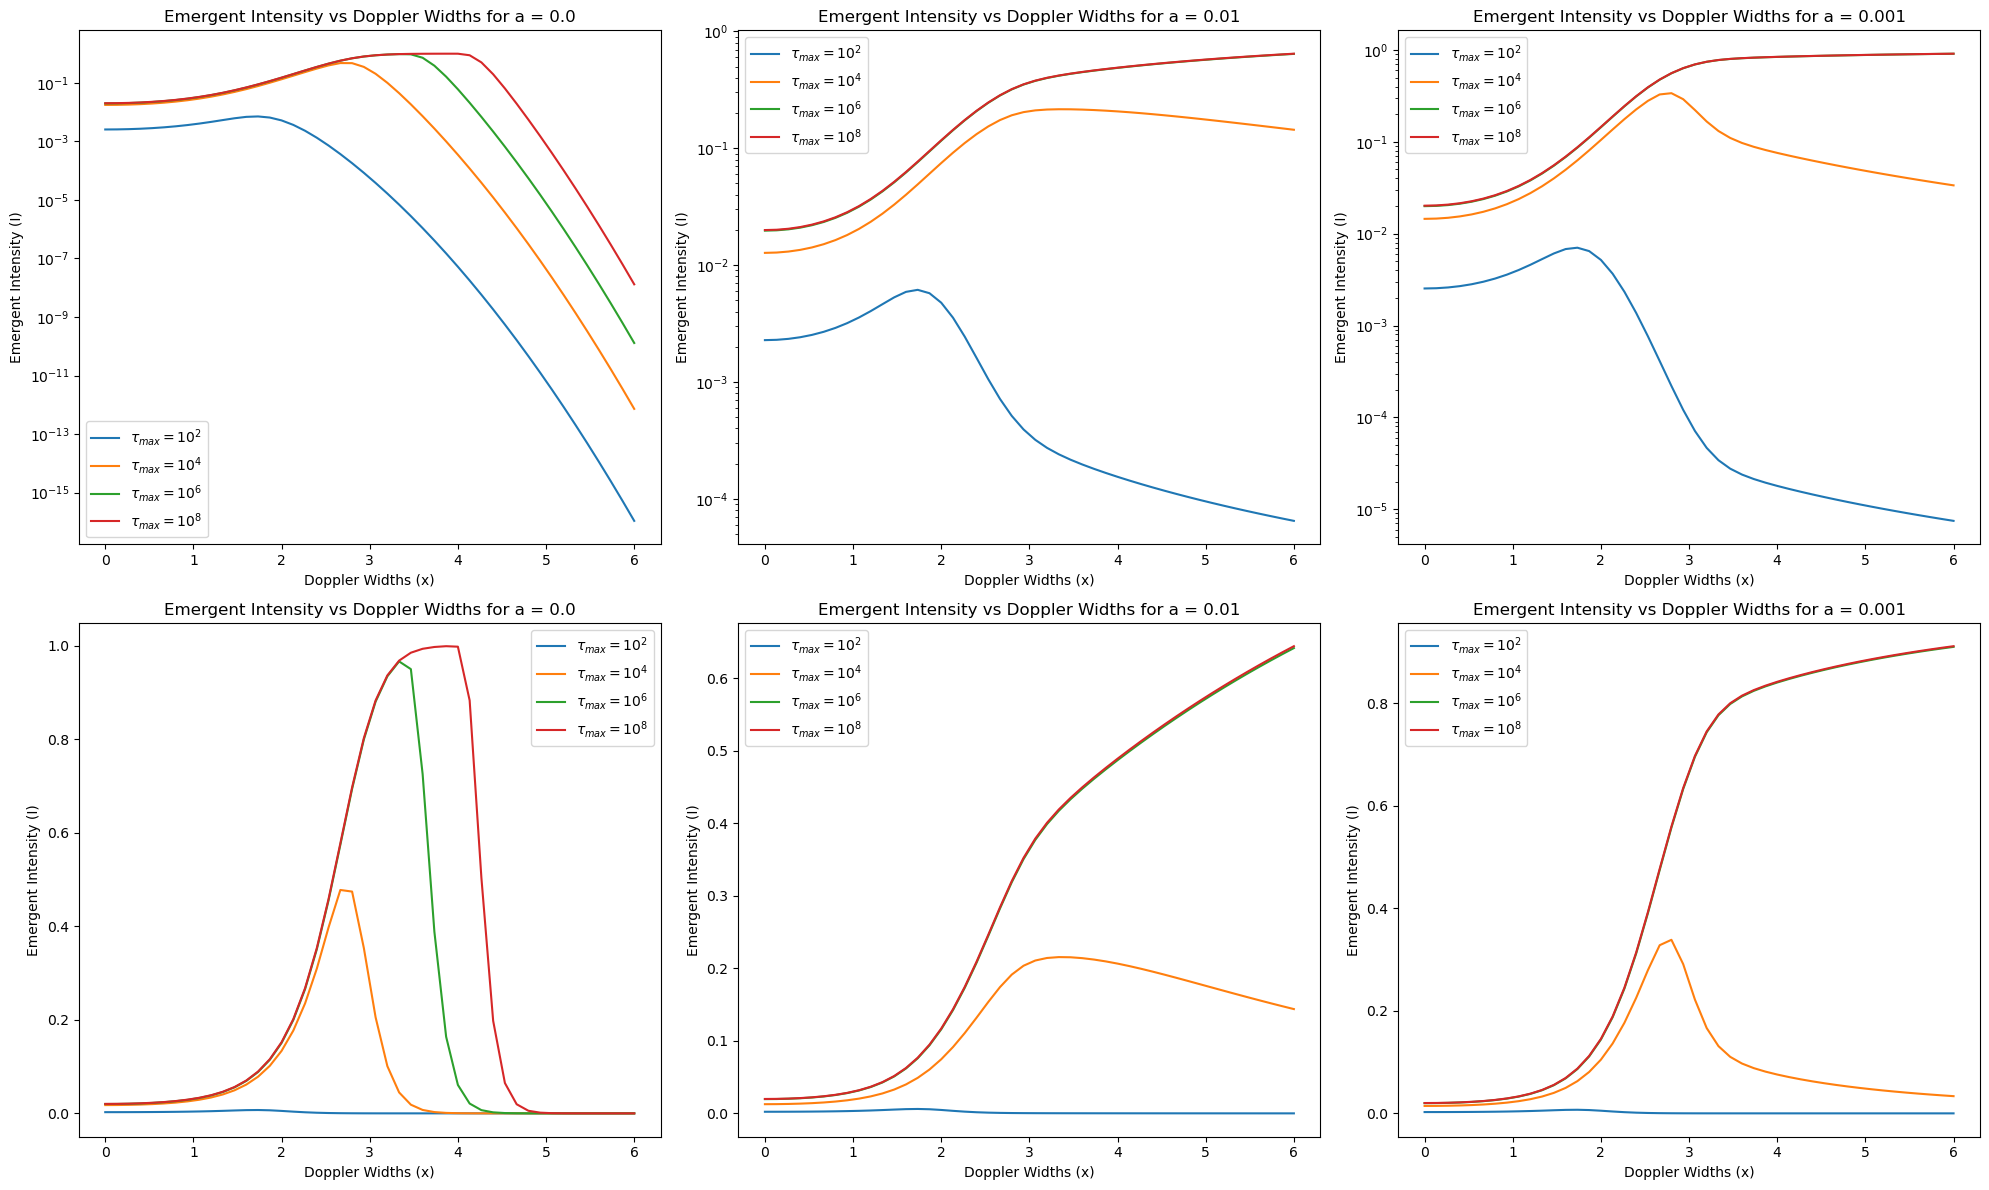

In [16]:
plt.figure(figsize=(20, 12))
midpoint = len(slab_one_line_dep2.x_values) // 2
mask = slab_one_line_dep2.x_values >= 0
plt.subplot(2, 3, 1)
plt.semilogy(slab_one_line_dep2.x_values[midpoint:][mask[midpoint:]], I_0_dep2[midpoint:][mask[midpoint:]], label=r'$\tau_{max} = 10^2$')
plt.semilogy(slab_one_line_dep4.x_values[midpoint:][mask[midpoint:]], I_0_dep4[midpoint:][mask[midpoint:]], label=r'$\tau_{max} = 10^4$')
plt.semilogy(slab_one_line_dep6.x_values[midpoint:][mask[midpoint:]], I_0_dep6[midpoint:][mask[midpoint:]], label=r'$\tau_{max} = 10^6$')
plt.semilogy(slab_one_line_dep8.x_values[midpoint:][mask[midpoint:]], I_0_dep8[midpoint:][mask[midpoint:]], label=r'$\tau_{max} = 10^8$')
plt.xlabel('Doppler Widths (x)')
plt.ylabel('Emergent Intensity (I)')
plt.title('Emergent Intensity vs Doppler Widths for a = 0.0')
plt.legend()
plt.subplot(2, 3, 2)
plt.semilogy(slab_one_line_dep2.x_values[midpoint:][mask[midpoint:]], I_02_dep2[midpoint:][mask[midpoint:]], label=r'$\tau_{max} = 10^2$')
plt.semilogy(slab_one_line_dep4.x_values[midpoint:][mask[midpoint:]], I_02_dep4[midpoint:][mask[midpoint:]], label=r'$\tau_{max} = 10^4$')
plt.semilogy(slab_one_line_dep6.x_values[midpoint:][mask[midpoint:]], I_02_dep6[midpoint:][mask[midpoint:]], label=r'$\tau_{max} = 10^6$')
plt.semilogy(slab_one_line_dep8.x_values[midpoint:][mask[midpoint:]], I_02_dep8[midpoint:][mask[midpoint:]], label=r'$\tau_{max} = 10^8$')
plt.xlabel('Doppler Widths (x)')
plt.ylabel('Emergent Intensity (I)')
plt.title('Emergent Intensity vs Doppler Widths for a = 0.01')
plt.legend()
plt.subplot(2, 3, 3)
plt.semilogy(slab_one_line_dep2.x_values[midpoint:][mask[midpoint:]], I_03_dep2[midpoint:][mask[midpoint:]], label=r'$\tau_{max} = 10^2$')
plt.semilogy(slab_one_line_dep4.x_values[midpoint:][mask[midpoint:]], I_03_dep4[midpoint:][mask[midpoint:]], label=r'$\tau_{max} = 10^4$')
plt.semilogy(slab_one_line_dep6.x_values[midpoint:][mask[midpoint:]], I_03_dep6[midpoint:][mask[midpoint:]], label=r'$\tau_{max} = 10^6$')
plt.semilogy(slab_one_line_dep8.x_values[midpoint:][mask[midpoint:]], I_03_dep8[midpoint:][mask[midpoint:]], label=r'$\tau_{max} = 10^8$')
plt.xlabel('Doppler Widths (x)')
plt.ylabel('Emergent Intensity (I)')
plt.title('Emergent Intensity vs Doppler Widths for a = 0.001')
plt.legend()
plt.subplot(2, 3, 4)
plt.plot(slab_one_line_dep2.x_values[midpoint:], I_0_dep2[midpoint:], label=r'$\tau_{max} = 10^2$')
plt.plot(slab_one_line_dep4.x_values[midpoint:], I_0_dep4[midpoint:], label=r'$\tau_{max} = 10^4$')
plt.plot(slab_one_line_dep6.x_values[midpoint:], I_0_dep6[midpoint:], label=r'$\tau_{max} = 10^6$')
plt.plot(slab_one_line_dep8.x_values[midpoint:], I_0_dep8[midpoint:], label=r'$\tau_{max} = 10^8$')
plt.xlabel('Doppler Widths (x)')
plt.ylabel('Emergent Intensity (I)')
plt.title('Emergent Intensity vs Doppler Widths for a = 0.0')
plt.legend()
plt.subplot(2, 3, 5)
plt.plot(slab_one_line_dep2.x_values[midpoint:], I_02_dep2[midpoint:], label=r'$\tau_{max} = 10^2$')
plt.plot(slab_one_line_dep4.x_values[midpoint:], I_02_dep4[midpoint:], label=r'$\tau_{max} = 10^4$')
plt.plot(slab_one_line_dep6.x_values[midpoint:], I_02_dep6[midpoint:], label=r'$\tau_{max} = 10^6$')
plt.plot(slab_one_line_dep8.x_values[midpoint:], I_02_dep8[midpoint:], label=r'$\tau_{max} = 10^8$')
plt.xlabel('Doppler Widths (x)')
plt.ylabel('Emergent Intensity (I)')
plt.title('Emergent Intensity vs Doppler Widths for a = 0.01')
plt.legend()
plt.subplot(2, 3, 6)
plt.plot(slab_one_line_dep2.x_values[midpoint:], I_03_dep2[midpoint:], label=r'$\tau_{max} = 10^2$')
plt.plot(slab_one_line_dep4.x_values[midpoint:], I_03_dep4[midpoint:], label=r'$\tau_{max} = 10^4$')
plt.plot(slab_one_line_dep6.x_values[midpoint:], I_03_dep6[midpoint:], label=r'$\tau_{max} = 10^6$')
plt.plot(slab_one_line_dep8.x_values[midpoint:], I_03_dep8[midpoint:], label=r'$\tau_{max} = 10^8$')
plt.xlabel('Doppler Widths (x)')
plt.ylabel('Emergent Intensity (I)')
plt.title('Emergent Intensity vs Doppler Widths for a = 0.001')
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
S_0_dep2_nu = result_one_0_dep2['S_nu']

In [18]:
np.shape(S_0_dep2_nu)

(91, 91)

In [19]:
print(slab_one_line_dep2.x_values)

[-6.         -5.86666667 -5.73333333 -5.6        -5.46666667 -5.33333333
 -5.2        -5.06666667 -4.93333333 -4.8        -4.66666667 -4.53333333
 -4.4        -4.26666667 -4.13333333 -4.         -3.86666667 -3.73333333
 -3.6        -3.46666667 -3.33333333 -3.2        -3.06666667 -2.93333333
 -2.8        -2.66666667 -2.53333333 -2.4        -2.26666667 -2.13333333
 -2.         -1.86666667 -1.73333333 -1.6        -1.46666667 -1.33333333
 -1.2        -1.06666667 -0.93333333 -0.8        -0.66666667 -0.53333333
 -0.4        -0.26666667 -0.13333333  0.          0.13333333  0.26666667
  0.4         0.53333333  0.66666667  0.8         0.93333333  1.06666667
  1.2         1.33333333  1.46666667  1.6         1.73333333  1.86666667
  2.          2.13333333  2.26666667  2.4         2.53333333  2.66666667
  2.8         2.93333333  3.06666667  3.2         3.33333333  3.46666667
  3.6         3.73333333  3.86666667  4.          4.13333333  4.26666667
  4.4         4.53333333  4.66666667  4.8         4

In [20]:
print(np.log10(slab_one_line_dep2.x_values[midpoint:]))

[       -inf -0.87506126 -0.57403127 -0.39794001 -0.27300127 -0.17609126
 -0.09691001 -0.02996322  0.02802872  0.07918125  0.12493874  0.16633142
  0.20411998  0.23888209  0.27106677  0.30103     0.32905872  0.35538766
  0.38021124  0.40369234  0.42596873  0.44715803  0.46736142  0.48666657
  0.50514998  0.52287875  0.53991208  0.5563025   0.57209677  0.58733673
  0.60205999  0.61630043  0.63008871  0.64345268  0.65641765  0.66900678
  0.68124124  0.69314046  0.70472233  0.71600334  0.72699873  0.73772259
  0.74818803  0.75840719  0.76839141  0.77815125]


/tmp/ipykernel_32560/1797604024.py:1: RuntimeWarning: divide by zero encountered in log10
  print(np.log10(slab_one_line_dep2.x_values[midpoint:]))


In [21]:
print(I_0_dep2[midpoint:])

[2.56620434e-03 2.58265773e-03 2.63320125e-03 2.72149042e-03
 2.85396744e-03 3.04036757e-03 3.29434402e-03 3.63397075e-03
 4.08141689e-03 4.65974004e-03 5.38032554e-03 6.20070860e-03
 6.92606903e-03 7.15812370e-03 6.55902926e-03 5.23821359e-03
 3.67696271e-03 2.31656090e-03 1.33935068e-03 7.23641774e-04
 3.70107534e-04 1.80687185e-04 8.46263079e-05 3.81333629e-05
 1.65576656e-05 6.93321580e-06 2.80080918e-06 1.09175887e-06
 4.10677789e-07 1.49081257e-07 5.22274648e-08 1.76575978e-08
 5.76132154e-09 1.81414007e-09 5.51287147e-10 1.61675165e-10
 4.57580143e-11 1.24982568e-11 3.29450472e-12 8.38087269e-13
 2.05753282e-13 4.87486639e-14 1.11464631e-14 2.45963047e-15
 5.23794660e-16 1.07649170e-16]


In [22]:
print("Minimum emergent intensity for tau_max = 10^2:", np.min(I_0_dep2[midpoint:]))
print("Maximum emergent intensity for tau_max = 10^2:", np.max(I_0_dep2[midpoint:]))
print("\n")
print("Minimum emergent intensity for tau_max = 10^4:", np.min(I_0_dep4[midpoint:]))
print("Maximum emergent intensity for tau_max = 10^4:", np.max(I_0_dep4[midpoint:]))
print("\n")
print("Minimum emergent intensity for tau_max = 10^6:", np.min(I_0_dep6[midpoint:]))
print("Maximum emergent intensity for tau_max = 10^6:", np.max(I_0_dep6[midpoint:]))
print("\n")
print("Minimum emergent intensity for tau_max = 10^8:", np.min(I_0_dep8[midpoint:]))
print("Maximum emergent intensity for tau_max = 10^8:", np.max(I_0_dep8[midpoint:]))

Minimum emergent intensity for tau_max = 10^2: 1.0764917006005978e-16
Maximum emergent intensity for tau_max = 10^2: 0.007158123696785949


Minimum emergent intensity for tau_max = 10^4: 7.24217426327257e-13
Maximum emergent intensity for tau_max = 10^4: 0.4776338681075727


Minimum emergent intensity for tau_max = 10^6: 1.2932208495055311e-10
Maximum emergent intensity for tau_max = 10^6: 0.9662592118903608


Minimum emergent intensity for tau_max = 10^8: 1.3084250457439344e-08
Maximum emergent intensity for tau_max = 10^8: 0.9988553549471467


<h2>12. 03. 2026.</h2>
<p>Here, we shall test the new iterative scheme which allows us to compute the source function for multiple lines simultaneously. We will start with the case of one line, and then we will move on to the case of two lines. We will compare the results with the case where we compute the source function for each line separately.</p>

In [23]:
it_res_one_slab = slab_one_line.iterative_scheme(lines_one, max_iter=2000, tol=1e-6, verbose=False)
it_res_one_slab_m4 = slab_one_line_m4.iterative_scheme(lines_one_m4, max_iter=2000, tol=1e-6, verbose=False)
it_res_one_slab_m6 = slab_one_line_m6.iterative_scheme(lines_one_m6, max_iter=2000, tol=1e-6, verbose=False)
it_res_one_slab_m8 = slab_one_line_m8.iterative_scheme(lines_one_m8, max_iter=2000, tol=1e-6, verbose=False)
it_res_one_slab_m10 = slab_one_line_m10.iterative_scheme(lines_one_m10, max_iter=2000, tol=1e-6, verbose=False) 

I_it_1 = it_res_one_slab['I_emergent']
I_it_1_m4 = it_res_one_slab_m4['I_emergent']
I_it_1_m6 = it_res_one_slab_m6['I_emergent']
I_it_1_m8 = it_res_one_slab_m8['I_emergent']
I_it_1_m10 = it_res_one_slab_m10['I_emergent']

S_it_1 = it_res_one_slab['S_lines'][0]
S_it_1_m4 = it_res_one_slab_m4['S_lines'][0]
S_it_1_m6 = it_res_one_slab_m6['S_lines'][0]
S_it_1_m8 = it_res_one_slab_m8['S_lines'][0]
S_it_1_m10 = it_res_one_slab_m10['S_lines'][0]

[[0.10018691 0.10018691 0.10018691 ... 0.10018691 0.10018691 0.10018691]
 [0.10024245 0.10024245 0.10024245 ... 0.10024245 0.10024245 0.10024245]
 [0.10032036 0.10032036 0.10032036 ... 0.10032036 0.10032036 0.10032036]
 ...
 [0.10032036 0.10032036 0.10032036 ... 0.10032036 0.10032036 0.10032036]
 [0.10024245 0.10024245 0.10024245 ... 0.10024245 0.10024245 0.10024245]
 [0.10018691 0.10018691 0.10018691 ... 0.10018691 0.10018691 0.10018691]]


100%|██████████| 2000/2000 [00:37<00:00, 52.91it/s]


[[0.00899863 0.00899863 0.00899863 ... 0.00899863 0.00899863 0.00899863]
 [0.00900375 0.00900375 0.00900375 ... 0.00900375 0.00900375 0.00900375]
 [0.00901093 0.00901093 0.00901093 ... 0.00901093 0.00901093 0.00901093]
 ...
 [0.00901093 0.00901093 0.00901093 ... 0.00901093 0.00901093 0.00901093]
 [0.00900375 0.00900375 0.00900375 ... 0.00900375 0.00900375 0.00900375]
 [0.00899863 0.00899863 0.00899863 ... 0.00899863 0.00899863 0.00899863]]


100%|██████████| 2000/2000 [00:38<00:00, 52.37it/s]


[[0.00016757 0.00016757 0.00016757 ... 0.00016757 0.00016757 0.00016757]
 [0.00016767 0.00016767 0.00016767 ... 0.00016767 0.00016767 0.00016767]
 [0.0001678  0.0001678  0.0001678  ... 0.0001678  0.0001678  0.0001678 ]
 ...
 [0.0001678  0.0001678  0.0001678  ... 0.0001678  0.0001678  0.0001678 ]
 [0.00016767 0.00016767 0.00016767 ... 0.00016767 0.00016767 0.00016767]
 [0.00016757 0.00016757 0.00016757 ... 0.00016757 0.00016757 0.00016757]]


100%|██████████| 2000/2000 [00:38<00:00, 51.28it/s]


[[1.80946076e-06 1.80946076e-06 1.80946076e-06 ... 1.80946076e-06
  1.80946076e-06 1.80946076e-06]
 [1.81049106e-06 1.81049106e-06 1.81049106e-06 ... 1.81049106e-06
  1.81049106e-06 1.81049106e-06]
 [1.81193638e-06 1.81193638e-06 1.81193638e-06 ... 1.81193638e-06
  1.81193638e-06 1.81193638e-06]
 ...
 [1.81193638e-06 1.81193638e-06 1.81193638e-06 ... 1.81193638e-06
  1.81193638e-06 1.81193638e-06]
 [1.81049106e-06 1.81049106e-06 1.81049106e-06 ... 1.81049106e-06
  1.81049106e-06 1.81049106e-06]
 [1.80946076e-06 1.80946076e-06 1.80946076e-06 ... 1.80946076e-06
  1.80946076e-06 1.80946076e-06]]


100%|██████████| 2000/2000 [00:39<00:00, 50.18it/s]


[[1.34221330e-07 1.34221330e-07 1.34221330e-07 ... 1.34221330e-07
  1.34221330e-07 1.34221330e-07]
 [1.34297836e-07 1.34297836e-07 1.34297836e-07 ... 1.34297836e-07
  1.34297836e-07 1.34297836e-07]
 [1.34405160e-07 1.34405160e-07 1.34405160e-07 ... 1.34405160e-07
  1.34405160e-07 1.34405160e-07]
 ...
 [1.34405157e-07 1.34405157e-07 1.34405157e-07 ... 1.34405157e-07
  1.34405157e-07 1.34405157e-07]
 [1.34297833e-07 1.34297833e-07 1.34297833e-07 ... 1.34297833e-07
  1.34297833e-07 1.34297833e-07]
 [1.34221327e-07 1.34221327e-07 1.34221327e-07 ... 1.34221327e-07
  1.34221327e-07 1.34221327e-07]]


100%|██████████| 2000/2000 [00:38<00:00, 52.48it/s]


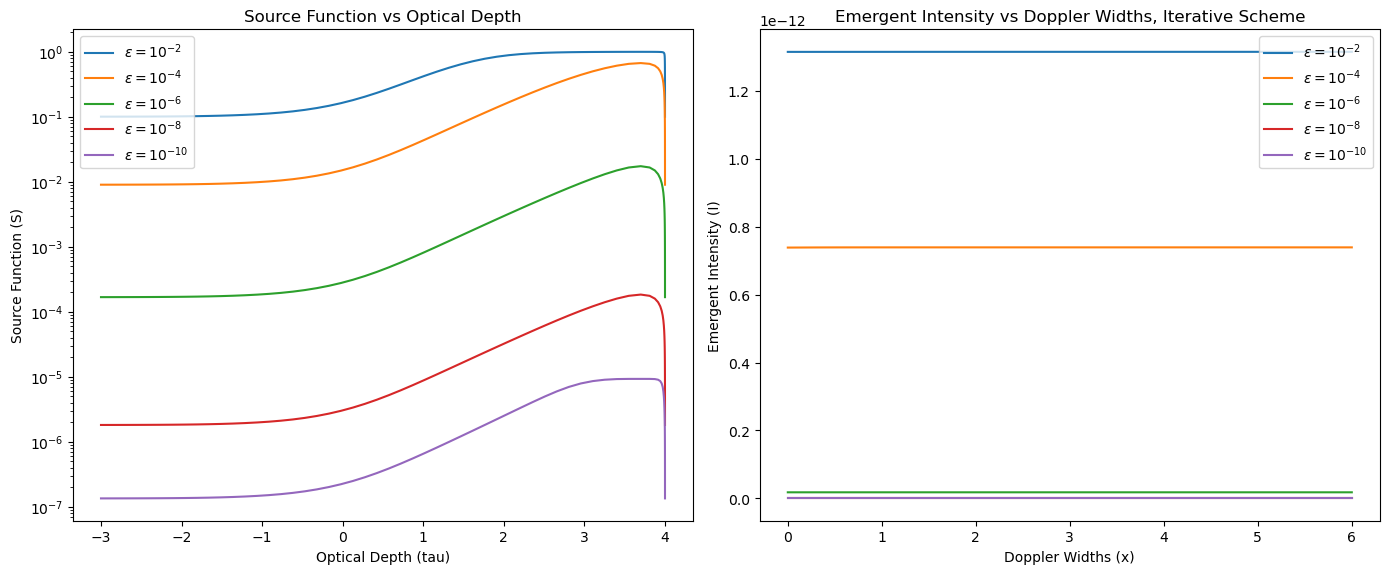

In [24]:
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.semilogy(np.log10(slab_one_line.tau), S_it_1, label=r'$\epsilon = 10^{-2}$')
plt.semilogy(np.log10(slab_one_line_m4.tau), S_it_1_m4, label=r'$\epsilon = 10^{-4}$')
plt.semilogy(np.log10(slab_one_line_m6.tau), S_it_1_m6, label=r'$\epsilon = 10^{-6}$')
plt.semilogy(np.log10(slab_one_line_m8.tau), S_it_1_m8, label=r'$\epsilon = 10^{-8}$')
plt.semilogy(np.log10(slab_one_line_m10.tau), S_it_1_m10, label=r'$\epsilon = 10^{-10}$')
plt.xlabel('Optical Depth (tau)')
plt.ylabel('Source Function (S)')
plt.title('Source Function vs Optical Depth')
plt.legend()
plt.subplot(1, 2, 2)
midpoint = len(slab_one_line.x_values) // 2
I_it_1_half = I_it_1[midpoint:]
I_it_1_m4_half = I_it_1_m4[midpoint:]
I_it_1_m6_half = I_it_1_m6[midpoint:]
I_it_1_m8_half = I_it_1_m8[midpoint:]
I_it_1_m10_half = I_it_1_m10[midpoint:]
plt.plot(slab_one_line.x_values[midpoint:], I_it_1_half, label=r'$\epsilon = 10^{-2}$')
plt.plot(slab_one_line_m4.x_values[midpoint:], I_it_1_m4_half, label=r'$\epsilon = 10^{-4}$')
plt.plot(slab_one_line_m6.x_values[midpoint:], I_it_1_m6_half, label=r'$\epsilon = 10^{-6}$')
plt.plot(slab_one_line_m8.x_values[midpoint:], I_it_1_m8_half, label=r'$\epsilon = 10^{-8}$')
plt.plot(slab_one_line_m10.x_values[midpoint:], I_it_1_m10_half, label=r'$\epsilon = 10^{-10}$')
plt.xlabel('Doppler Widths (x)')
plt.ylabel('Emergent Intensity (I)')
plt.title('Emergent Intensity vs Doppler Widths, Iterative Scheme')
plt.legend()
plt.tight_layout()
plt.show()